In [1]:
import os, gc, re, json, warnings
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import pandas as pd
import polars as pl
import duckdb

from tqdm.auto import tqdm
from scipy import stats
from scipy.sparse import csr_matrix

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pl.Config.set_tbl_cols(100)
pl.Config.set_tbl_rows(100)

polars.config.Config

# 1. Data extraction

In [2]:
DATA_DIR = Path("/kaggle/input/competitions/detect-suspicious-value-transfers-in-poker")

PLAYERS_PATH = DATA_DIR / "players.parquet"
HANDS_PATH = DATA_DIR / "hands.parquet"
SEATS_PATH = DATA_DIR / "seats.parquet"
ACTIONS_PATH = DATA_DIR / "actions.parquet"
DEV_LABELS_PATH = DATA_DIR / "development_labels.csv"
DEV_EVIDENCE_PATH = DATA_DIR / "development_evidence.csv"
EVAL_PAIRS_PATH = DATA_DIR / "evaluation_pairs.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

In [3]:
players = pl.scan_parquet(PLAYERS_PATH)
hands = pl.scan_parquet(HANDS_PATH)
seats = pl.scan_parquet(SEATS_PATH)
actions = pl.scan_parquet(ACTIONS_PATH)

dev_labels = pl.read_csv(DEV_LABELS_PATH)
dev_evidence = pl.read_csv(DEV_EVIDENCE_PATH)
eval_pairs = pl.read_csv(EVAL_PAIRS_PATH)
sample_sub = pl.read_csv(SAMPLE_SUB_PATH)

In [4]:
tables = {
    "players": players, "hands": hands, "seats": seats, "actions": actions, 
    "dev_labels": dev_labels, "dev_evidence": dev_evidence, "eval_pairs": eval_pairs, 
    "sample_sub": sample_sub
}

In [5]:
for name, df in tqdm(tables.items()):
    n = df.select(pl.len()).collect().item() if isinstance(df, pl.LazyFrame) else len(df)
    print(f"{name:<15} | {n:>12,} rows")

  0%|          | 0/8 [00:00<?, ?it/s]

players         |       12,000 rows
hands           |    2,000,000 rows
seats           |   12,000,000 rows
actions         |   18,609,028 rows
dev_labels      |        1,860 rows
dev_evidence    |        1,817 rows
eval_pairs      |      112,540 rows
sample_sub      |      112,540 rows


In [6]:
display(players.head(5).collect())
display(hands.head(5).collect())
display(seats.head(5).collect())
display(actions.head(5).collect())

player_id,account_age_days,experience_hands_bucket,preferred_stake,region_bucket,client_family
str,i64,str,str,str,str
"""U5633D3A823B3""",1398,"""developing""","""micro""","""americas""","""mobile"""
"""U24301F6A1C50""",1733,"""experienced""","""mid""","""americas""","""desktop"""
"""U677A590AD158""",385,"""developing""","""low""","""europe""","""desktop"""
"""UD579445488E5""",1114,"""developing""","""micro""","""apac""","""desktop"""
"""U5897FE016641""",2360,"""new""","""low""","""americas""","""desktop"""


hand_id,table_id,started_at,phase,button_seat,small_blind,big_blind,board_cards,final_pot,players_dealt,players_at_showdown
str,str,"datetime[μs, UTC]",str,i64,i64,i64,str,i64,i64,i64
"""HE5FDF711A04BD5""","""T4EF53C3C""",2026-01-01 00:54:26.575570 UTC,"""development""",2,2,4,"""5d Jd 9d""",41,6,0
"""H31B925426D2CCF""","""T1ED83D50""",2026-01-01 00:41:13.129452 UTC,"""development""",1,2,4,"""7h Th 7d Kc""",107,6,0
"""H8C2B1CE1BAFDAC""","""T11EC664A""",2026-01-01 00:42:25.477486 UTC,"""development""",0,1,2,"""""",8,6,0
"""H7898C33774CAAF""","""T4737D804""",2026-01-01 00:34:01.723749 UTC,"""development""",1,1,2,"""Ac Jh 9d""",16,6,0
"""H9825B7C6E8BAF2""","""TBF352E72""",2026-01-01 00:11:01.180979 UTC,"""development""",0,1,2,"""2h 6s Jc""",21,6,0


hand_id,player_id,seat_no,starting_stack,hole_card_1,hole_card_2,total_contribution,net_chips,folded,went_to_showdown,won_share
str,str,i64,i64,str,str,i64,i64,bool,bool,f64
"""HE5FDF711A04BD5""","""U31A44DD58B84""",0,471,"""Ah""","""9h""",10,-10,true,false,0.0
"""HE5FDF711A04BD5""","""UD6B35A373EA7""",1,505,"""Kh""","""5c""",0,0,true,false,0.0
"""HE5FDF711A04BD5""","""U142270AC9652""",2,343,"""9s""","""Qh""",25,16,false,false,1.0
"""HE5FDF711A04BD5""","""U301DCE814AFB""",3,441,"""8d""","""Ks""",2,-2,true,false,0.0
"""HE5FDF711A04BD5""","""UACB7A04C1567""",4,624,"""3h""","""Js""",4,-4,true,false,0.0


hand_id,action_no,street,player_id,action,amount,amount_to,pot_before,stack_before,to_call,players_active
str,i64,str,str,str,i64,i64,i64,i64,i64,i64
"""HE5FDF711A04BD5""",0,"""preflop""","""UA62E03411020""","""fold""",0,0,6,375,4,6
"""HE5FDF711A04BD5""",1,"""preflop""","""U31A44DD58B84""","""raise""",10,10,6,471,4,5
"""HE5FDF711A04BD5""",2,"""preflop""","""UD6B35A373EA7""","""fold""",0,0,16,505,10,5
"""HE5FDF711A04BD5""",3,"""preflop""","""U142270AC9652""","""call""",10,10,16,343,10,4
"""HE5FDF711A04BD5""",4,"""preflop""","""U301DCE814AFB""","""fold""",0,2,26,439,8,4


In [7]:
display(dev_labels.head())
display(dev_evidence.head())
display(eval_pairs.head())
display(sample_sub.head())

pair_id,player_1,player_2,label,label_status,behavior_family
str,str,str,i64,str,str
"""P00082F54BA9A""","""UB2461B374353""","""UB7007B0BB213""",1,"""confirmed_target""","""soft_play"""
"""P000E2B8237C8""","""UA739845D9FF6""","""UC96B43AAE1A3""",0,"""confirmed_non_target""","""none"""
"""P00191F741BB2""","""U1CE17E75CDAC""","""U95D7797BFE34""",0,"""confirmed_non_target""","""none"""
"""P005EA17605A2""","""U5BA367793CFE""","""UC9363E45823A""",1,"""confirmed_target""","""directed_transfer"""
"""P008B5B4265F0""","""U71034B61E5F2""","""UF305D223C434""",0,"""confirmed_non_target""","""none"""


pair_id,evidence_rank,hand_id,behavior_family
str,i64,str,str
"""P00082F54BA9A""",1,"""H2D8EAC9EC7DA02""","""soft_play"""
"""P00082F54BA9A""",2,"""HF67EF16BB8EF76""","""soft_play"""
"""P00082F54BA9A""",3,"""HD9B5F56C491E2D""","""soft_play"""
"""P00082F54BA9A""",4,"""HB08845B500469E""","""soft_play"""
"""P00082F54BA9A""",5,"""HB77EC3F2086CC2""","""soft_play"""


pair_id,player_1,player_2,shared_hands
str,str,str,i64
"""P00005AC2A509""","""U6C0B3CD15EFC""","""U9FCB0A662151""",51
"""P00055C6C3588""","""U03CE4AB57192""","""UA66C8B32642F""",207
"""P0007B4930526""","""U2C028297A8BC""","""U4D441D74E1CB""",145
"""P000841AC274F""","""U02908E244BCB""","""U60A744235677""",65
"""P0008F9A8AD1F""","""U04F6F51F1B54""","""U80A85A0EB9F6""",68


pair_id,risk_score,predicted_behavior,evidence_hand_1,evidence_hand_2,evidence_hand_3,evidence_hand_4,evidence_hand_5
str,f64,str,str,str,str,str,str
"""P00005AC2A509""",0.0,"""none""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE"""
"""P00055C6C3588""",0.0,"""none""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE"""
"""P0007B4930526""",0.0,"""none""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE"""
"""P000841AC274F""",0.0,"""none""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE"""
"""P0008F9A8AD1F""",0.0,"""none""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE""","""NO_EVIDENCE"""


# 2. Data analysis

Explore the label structure, evidence coverage, pair exposure, and gameplay distributions. The goal is to identify the strongest directions for pair-level feature engineering and evidence-hand ranking.

In [8]:
label_summary = dev_labels.group_by(["label", "label_status", "behavior_family"]).agg(pl.len().alias("pairs")).sort(["label", "behavior_family"])
display(label_summary)

n_pos = dev_labels.filter(pl.col("label") == 1).height
n_neg = dev_labels.filter(pl.col("label") == 0).height
print(f"Confirmed targets:     {n_pos:,}")
print(f"Confirmed non-targets: {n_neg:,}")
print(f"Positive rate:         {n_pos / len(dev_labels):.2%}")

label,label_status,behavior_family,pairs
i64,str,str,u32
0,"""confirmed_non_target""","""none""",1488
1,"""confirmed_target""","""coordinated_isolation""",92
1,"""confirmed_target""","""directed_transfer""",148
1,"""confirmed_target""","""soft_play""",132


Confirmed targets:     372
Confirmed non-targets: 1,488
Positive rate:         20.00%


In [9]:
evidence_per_pair = dev_evidence.group_by(["pair_id", "behavior_family"]).agg(pl.len().alias("n_evidence"), pl.max("evidence_rank").alias("max_rank"))

positive_evidence = dev_labels.filter(pl.col("label") == 1).select(["pair_id", "behavior_family"]).join(evidence_per_pair, on=["pair_id", "behavior_family"], how="left")

display(positive_evidence.group_by(["behavior_family", "n_evidence"]).agg(pl.len().alias("pairs")).sort(["behavior_family", "n_evidence"]))

print(f"Positive pairs:          {len(positive_evidence):,}")
print(f"Pairs without evidence:  {positive_evidence['n_evidence'].null_count():,}")
print(f"Total evidence hands:    {len(dev_evidence):,}")

behavior_family,n_evidence,pairs
str,u32,u32
"""coordinated_isolation""",5,92
"""directed_transfer""",3,4
"""directed_transfer""",4,7
"""directed_transfer""",5,137
"""soft_play""",3,7
"""soft_play""",4,14
"""soft_play""",5,111


Positive pairs:          372
Pairs without evidence:  0
Total evidence hands:    1,817


In [10]:
shared_stats = eval_pairs.select(
    pl.len().alias("pairs"),
    pl.col("shared_hands").min().alias("min"),
    pl.col("shared_hands").quantile(0.01).alias("p01"),
    pl.col("shared_hands").quantile(0.10).alias("p10"),
    pl.col("shared_hands").median().alias("median"),
    pl.col("shared_hands").mean().alias("mean"),
    pl.col("shared_hands").quantile(0.90).alias("p90"),
    pl.col("shared_hands").quantile(0.99).alias("p99"),
    pl.col("shared_hands").max().alias("max")
)
display(shared_stats)

pairs,min,p01,p10,median,mean,p90,p99,max
u32,i64,f64,f64,f64,f64,f64,f64,i64
112540,38,38.0,45.0,76.0,85.763462,140.0,212.0,419


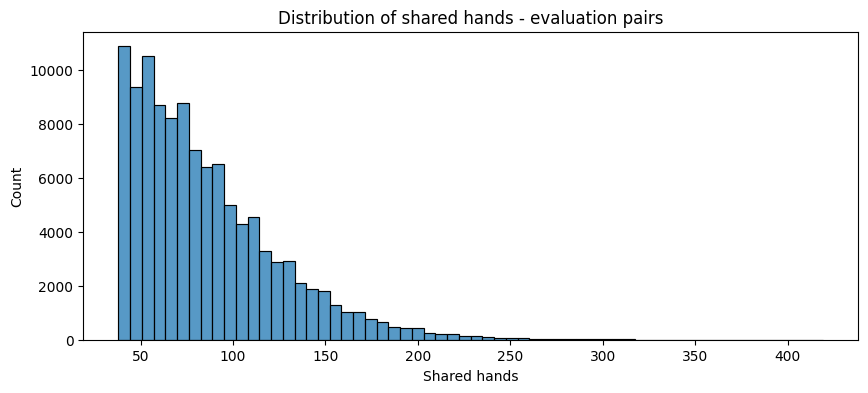

In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(eval_pairs["shared_hands"].to_numpy(), bins=60)
plt.title("Distribution of shared hands - evaluation pairs")
plt.xlabel("Shared hands")
plt.show()

In [12]:
hand_overview = hands.group_by("phase").agg(
    pl.len().alias("hands"),
    pl.col("table_id").n_unique().alias("tables"),
    pl.col("final_pot").mean().alias("mean_pot"),
    pl.col("final_pot").median().alias("median_pot"),
    pl.col("players_at_showdown").mean().alias("mean_showdown_players")
).collect().sort("phase")

display(hand_overview)

phase,hands,tables,mean_pot,median_pot,mean_showdown_players
str,u32,u32,f64,f64,f64
"""development""",1200000,400,113.241033,23.0,0.3247825
"""evaluation""",800000,400,118.244425,25.0,0.337025


In [13]:
stake_dist = hands.group_by(["phase", "small_blind", "big_blind"]).agg(pl.len().alias("hands")).collect().sort(["small_blind", "big_blind", "phase"])
display(stake_dist)

phase,small_blind,big_blind,hands
str,i64,i64,u32
"""development""",1,2,654000
"""evaluation""",1,2,436000
"""development""",2,4,429000
"""evaluation""",2,4,286000
"""development""",5,10,117000
"""evaluation""",5,10,78000


In [14]:
action_dist = actions.group_by(["street", "action"]).agg(
    pl.len().alias("actions"),
    pl.col("amount").mean().alias("mean_amount"),
    pl.col("to_call").mean().alias("mean_to_call"),
    pl.col("pot_before").mean().alias("mean_pot")
).collect().sort(["street", "actions"], descending=[False, True])

display(action_dist)

street,action,actions,mean_amount,mean_to_call,mean_pot
str,str,u32,f64,f64,f64
"""flop""","""check""",1035529,0.0,0.0,33.85616
"""flop""","""bet""",729599,23.339452,0.0,36.647016
"""flop""","""fold""",645891,0.0,26.856,68.277804
"""flop""","""call""",354809,31.042448,31.042448,87.323422
"""flop""","""raise""",73458,97.63929,28.050696,73.99853
"""flop""","""all_in""",13133,175.461814,103.407675,600.910607
"""preflop""","""fold""",8582073,0.0,7.464297,17.32393
"""preflop""","""raise""",2254879,18.765925,6.012429,14.119054
"""preflop""","""call""",2166725,9.197356,9.197356,23.079818


In [15]:
street_dist = actions.group_by("street").agg(
    pl.len().alias("actions"),
    pl.col("hand_id").n_unique().alias("hands"),
    pl.col("players_active").mean().alias("mean_players_active")
).collect().sort("actions", descending=True)

display(street_dist)

street,actions,hands,mean_players_active
str,u32,u32,f64
"""preflop""",13228162,2000000,4.173414
"""flop""",2852419,1043608,2.419247
"""turn""",1614275,611899,2.267834
"""river""",914172,359754,2.169478


In [16]:
seat_stats = seats.select(
    pl.col("starting_stack").mean().alias("mean_stack"),
    pl.col("starting_stack").median().alias("median_stack"),
    pl.col("total_contribution").mean().alias("mean_contribution"),
    pl.col("total_contribution").median().alias("median_contribution"),
    pl.col("total_contribution").quantile(.95).alias("contribution_p95"),
    pl.col("net_chips").quantile(.05).alias("net_p05"),
    pl.col("net_chips").median().alias("net_median"),
    pl.col("net_chips").quantile(.95).alias("net_p95")
).collect()

display(seat_stats)

mean_stack,median_stack,mean_contribution,median_contribution,contribution_p95,net_p05,net_median,net_p95
f64,f64,f64,f64,f64,f64,f64,f64
418.399883,317.0,19.207065,1.0,89.0,-22.0,0.0,20.0


In [17]:
seat_outcomes = seats.group_by(["folded", "went_to_showdown"]).agg(
    pl.len().alias("rows"),
    pl.col("total_contribution").mean().alias("mean_contribution"),
    pl.col("net_chips").mean().alias("mean_net_chips"),
    pl.col("won_share").mean().alias("mean_won_share")
).collect().sort("rows", descending=True)

display(seat_outcomes)

folded,went_to_showdown,rows,mean_contribution,mean_net_chips,mean_won_share
bool,bool,u32,f64,f64,f64
true,false,9652383,3.893009,-3.893009,0.0
false,false,1688258,35.072836,19.075563,1.0
false,true,659359,202.766573,8.147833,0.472796


In [18]:
display(players.select(
    pl.col("account_age_days").min().alias("min_age"),
    pl.col("account_age_days").median().alias("median_age"),
    pl.col("account_age_days").mean().alias("mean_age"),
    pl.col("account_age_days").max().alias("max_age")
).collect())

for col in ["experience_hands_bucket", "preferred_stake", "region_bucket", "client_family"]:
    print(f"\n{col}")
    display(players.group_by(col).agg(pl.len().alias("players")).collect().sort("players", descending=True))

min_age,median_age,mean_age,max_age
i64,f64,f64,i64
10,1261.0,1257.376667,2499



experience_hands_bucket


experience_hands_bucket,players
str,u32
"""experienced""",4588
"""developing""",3299
"""veteran""",2702
"""new""",1411



preferred_stake


preferred_stake,players
str,u32
"""micro""",6595
"""low""",4198
"""mid""",1207



region_bucket


region_bucket,players
str,u32
"""americas""",4584
"""europe""",4031
"""apac""",2672
"""other""",713



client_family


client_family,players
str,u32
"""desktop""",5876
"""mobile""",4344
"""web""",1780


## 2.1. Evidence analysis

Study the planted evidence hands and compare them against ordinary shared hands from the same positive pairs. This helps identify the action patterns that characterize each coordination behavior while controlling for player-specific style.

In [19]:
pos_pairs = dev_labels.filter(pl.col("label") == 1).select(["pair_id", "player_1", "player_2", "behavior_family"])

pos_players = pl.concat([
    pos_pairs.select(["pair_id", pl.col("player_1").alias("player_id")]).with_columns(pl.lit("p1").alias("role")),
    pos_pairs.select(["pair_id", pl.col("player_2").alias("player_id")]).with_columns(pl.lit("p2").alias("role"))
])

evidence_keys = dev_evidence.select(["pair_id", "hand_id"]).with_columns(pl.lit(True).alias("is_evidence"))

pos_shared = (seats.join(pos_players.lazy(), on="player_id", how="inner")
    .group_by(["pair_id", "hand_id"]).agg(pl.col("player_id").n_unique().alias("n_pair_players"))
    .filter(pl.col("n_pair_players") == 2)
    .join(hands.select(["hand_id", "phase", "table_id", "big_blind", "final_pot"]), on="hand_id")
    .filter(pl.col("phase") == "development").collect()
    .join(pos_pairs.select(["pair_id", "behavior_family"]), on="pair_id")
    .join(evidence_keys, on=["pair_id", "hand_id"], how="left")
    .with_columns(pl.col("is_evidence").fill_null(False)).drop("n_pair_players"))

display(pos_shared.group_by("behavior_family").agg(
    pl.len().alias("shared_hands"),
    pl.col("pair_id").n_unique().alias("pairs"),
    pl.col("is_evidence").sum().alias("evidence_hands"),
    (pl.col("is_evidence").mean() * 100).alias("evidence_pct")
).sort("behavior_family"))

behavior_family,shared_hands,pairs,evidence_hands,evidence_pct
str,u32,u32,u32,f64
"""coordinated_isolation""",11280,92,460,4.078014
"""directed_transfer""",18150,148,725,3.99449
"""soft_play""",15699,132,632,4.025734


In [20]:
pair_seats = (seats.join(pos_players.lazy(), on="player_id", how="inner")
    .join(pos_shared.lazy().select(["pair_id", "hand_id", "behavior_family", "is_evidence", "big_blind", "final_pot"]), on=["pair_id", "hand_id"], how="inner")
    .with_columns(
        (pl.col("starting_stack") / pl.col("big_blind")).alias("stack_bb"),
        (pl.col("total_contribution") / pl.col("big_blind")).alias("contribution_bb"),
        (pl.col("net_chips") / pl.col("big_blind")).alias("net_bb"),
        (pl.col("final_pot") / pl.col("big_blind")).alias("pot_bb")
    ).collect())

pair_hand_outcomes = pair_seats.group_by(["pair_id", "hand_id", "behavior_family", "is_evidence"]).agg(
    pl.col("contribution_bb").sum().alias("pair_contribution_bb"),
    pl.col("contribution_bb").max().alias("max_contribution_bb"),
    pl.col("net_bb").max().alias("max_win_bb"),
    pl.col("net_bb").min().alias("max_loss_bb"),
    (pl.col("net_bb").max() - pl.col("net_bb").min()).alias("net_gap_bb"),
    pl.col("went_to_showdown").sum().alias("pair_showdowns"),
    pl.col("pot_bb").first().alias("pot_bb")
)

display(pair_hand_outcomes.group_by(["behavior_family", "is_evidence"]).agg(
    pl.len().alias("hands"),
    pl.col("pot_bb").median().alias("median_pot_bb"),
    pl.col("pair_contribution_bb").median().alias("median_pair_contribution_bb"),
    pl.col("net_gap_bb").median().alias("median_net_gap_bb"),
    pl.col("net_gap_bb").quantile(.90).alias("p90_net_gap_bb"),
    pl.col("pair_showdowns").mean().alias("mean_pair_showdowns")
).sort(["behavior_family", "is_evidence"]))

behavior_family,is_evidence,hands,median_pot_bb,median_pair_contribution_bb,median_net_gap_bb,p90_net_gap_bb,mean_pair_showdowns
str,bool,u32,f64,f64,f64,f64,f64
"""coordinated_isolation""",false,10820,10.0,2.5,1.5,23.5,0.123567
"""coordinated_isolation""",true,460,17.75,9.0,6.0,51.5,0.143478
"""directed_transfer""",false,17425,10.5,2.5,1.5,45.5,0.19363
"""directed_transfer""",true,725,34.5,29.5,17.0,188.5,0.526897
"""soft_play""",false,15067,10.0,2.2,1.0,23.9,0.176412
"""soft_play""",true,632,17.0,12.4,9.0,81.5,0.803797


In [21]:
pair_actions = (actions.join(pos_players.lazy(), on="player_id", how="inner")
    .join(pos_shared.lazy().select(["pair_id", "hand_id", "behavior_family", "is_evidence", "big_blind"]), on=["pair_id", "hand_id"], how="inner")
    .with_columns(
        (pl.col("amount") / pl.col("big_blind")).alias("amount_bb"),
        (pl.col("amount_to") / pl.col("big_blind")).alias("amount_to_bb"),
        (pl.col("to_call") / pl.col("big_blind")).alias("to_call_bb"),
        (pl.col("pot_before") / pl.col("big_blind")).alias("pot_before_bb")
    ).collect())

print(f"{len(pair_actions):,} pair-player actions")

159,748 pair-player actions


In [22]:
action_mix = (pair_actions.group_by(["behavior_family", "is_evidence", "action"]).agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / pl.col("n").sum().over(["behavior_family", "is_evidence"]) * 100).alias("share_pct"))
    .sort(["behavior_family", "is_evidence", "share_pct"], descending=[False, False, True]))

display(action_mix)

behavior_family,is_evidence,action,n,share_pct
str,bool,str,u32,f64
"""coordinated_isolation""",false,"""fold""",16933,49.172378
"""coordinated_isolation""",false,"""raise""",6205,18.018934
"""coordinated_isolation""",false,"""call""",4943,14.354164
"""coordinated_isolation""",false,"""check""",3239,9.405854
"""coordinated_isolation""",false,"""bet""",2667,7.744802
"""coordinated_isolation""",false,"""all_in""",449,1.303868
"""coordinated_isolation""",true,"""raise""",719,40.235031
"""coordinated_isolation""",true,"""fold""",615,34.415221
"""coordinated_isolation""",true,"""check""",162,9.065473


In [23]:
pair_hand_actions = pair_actions.group_by(["pair_id", "hand_id", "behavior_family", "is_evidence"]).agg(
    pl.len().alias("n_actions"),
    pl.col("action").is_in(["bet", "raise", "all_in"]).sum().alias("aggressive_actions"),
    (pl.col("action") == "raise").sum().alias("raises"),
    (pl.col("action") == "all_in").sum().alias("all_ins"),
    (pl.col("action") == "check").sum().alias("checks"),
    (pl.col("action") == "call").sum().alias("calls"),
    (pl.col("action") == "fold").sum().alias("folds"),
    ((pl.col("action") == "fold") & (pl.col("to_call") > 0)).sum().alias("folds_facing_bet"),
    (pl.col("players_active") == 2).sum().alias("heads_up_actions"),
    (pl.col("street") == "river").sum().alias("river_actions"),
    pl.col("amount_bb").max().alias("max_amount_bb"),
    pl.col("to_call_bb").max().alias("max_to_call_bb"),
    pl.col("pot_before_bb").max().alias("max_seen_pot_bb")
)

display(pair_hand_actions.group_by(["behavior_family", "is_evidence"]).agg(
    pl.len().alias("hands"),
    pl.col("aggressive_actions").mean().alias("mean_aggression"),
    pl.col("raises").mean().alias("mean_raises"),
    pl.col("checks").mean().alias("mean_checks"),
    pl.col("folds_facing_bet").mean().alias("mean_pressure_folds"),
    pl.col("heads_up_actions").mean().alias("mean_heads_up_actions"),
    pl.col("max_amount_bb").median().alias("median_max_amount_bb"),
    pl.col("max_to_call_bb").median().alias("median_max_to_call_bb")
).sort(["behavior_family", "is_evidence"]))

behavior_family,is_evidence,hands,mean_aggression,mean_raises,mean_checks,mean_pressure_folds,mean_heads_up_actions,median_max_amount_bb,median_max_to_call_bb
str,bool,u32,f64,f64,f64,f64,f64,f64,f64
"""coordinated_isolation""",false,10820,0.86146,0.573475,0.299353,1.564972,0.9561,2.0,2.5
"""coordinated_isolation""",true,460,1.88913,1.563043,0.352174,1.336957,1.102174,6.15,6.25
"""directed_transfer""",false,17425,0.91208,0.499799,0.312539,1.537331,1.07495,2.0,2.5
"""directed_transfer""",true,725,2.811034,1.231724,0.81931,0.750345,3.228966,15.0,14.0
"""soft_play""",false,15067,0.61419,0.306232,0.551072,1.575164,1.032654,1.5,2.2
"""soft_play""",true,632,1.681962,0.748418,2.481013,0.732595,2.89557,5.55,6.0


In [24]:
def show_hand(pair_id, hand_id):
    pair = pos_pairs.filter(pl.col("pair_id") == pair_id).row(0, named=True)
    p1, p2 = pair["player_1"], pair["player_2"]

    print(f"\nPAIR {pair_id} | {pair['behavior_family']} | {hand_id}")
    display(hands.filter(pl.col("hand_id") == hand_id).select(["hand_id", "table_id", "big_blind", "board_cards", "final_pot", "players_at_showdown"]).collect())

    hand_seats = (seats.filter(pl.col("hand_id") == hand_id).collect()
        .with_columns(pl.when(pl.col("player_id") == p1).then(pl.lit("P1")).when(pl.col("player_id") == p2).then(pl.lit("P2")).otherwise(pl.lit("")).alias("pair_role"))
        .select(["pair_role", "player_id", "seat_no", "starting_stack", "hole_card_1", "hole_card_2", "total_contribution", "net_chips", "folded", "went_to_showdown", "won_share"]))
    display(hand_seats)

    hand_actions = (actions.filter(pl.col("hand_id") == hand_id).collect()
        .with_columns(pl.when(pl.col("player_id") == p1).then(pl.lit("P1")).when(pl.col("player_id") == p2).then(pl.lit("P2")).otherwise(pl.lit("")).alias("pair_role"))
        .select(["action_no", "street", "pair_role", "player_id", "action", "amount", "amount_to", "pot_before", "stack_before", "to_call", "players_active"]))
    display(hand_actions)

examples = dev_evidence.filter(pl.col("evidence_rank") == 1).sort("pair_id").group_by("behavior_family", maintain_order=True).first()

for row in examples.iter_rows(named=True):
    show_hand(row["pair_id"], row["hand_id"])


PAIR P00082F54BA9A | soft_play | H2D8EAC9EC7DA02


hand_id,table_id,big_blind,board_cards,final_pot,players_at_showdown
str,str,i64,str,i64,i64
"""H2D8EAC9EC7DA02""","""TAF38C298""",4,"""""",18,0


pair_role,player_id,seat_no,starting_stack,hole_card_1,hole_card_2,total_contribution,net_chips,folded,went_to_showdown,won_share
str,str,i64,i64,str,str,i64,i64,bool,bool,f64
"""""","""U87091E66B371""",0,462,"""2s""","""9d""",0,0,true,false,0.0
"""""","""U4BB39F0AE9E9""",1,391,"""Kc""","""7s""",0,0,true,false,0.0
"""""","""U45193F940E30""",2,411,"""2h""","""2d""",0,0,true,false,0.0
"""P1""","""UB2461B374353""",3,400,"""4s""","""9s""",10,8,false,false,1.0
"""""","""U6414A133CF93""",4,750,"""8d""","""6s""",4,-4,true,false,0.0
"""P2""","""UB7007B0BB213""",5,356,"""Td""","""6c""",4,-4,true,false,0.0


action_no,street,pair_role,player_id,action,amount,amount_to,pot_before,stack_before,to_call,players_active
i64,str,str,str,str,i64,i64,i64,i64,i64,i64
0,"""preflop""","""P2""","""UB7007B0BB213""","""call""",4,4,6,356,4,6
1,"""preflop""","""""","""U87091E66B371""","""fold""",0,0,10,462,4,6
2,"""preflop""","""""","""U4BB39F0AE9E9""","""fold""",0,0,10,391,4,5
3,"""preflop""","""""","""U45193F940E30""","""fold""",0,0,10,411,4,4
4,"""preflop""","""P1""","""UB2461B374353""","""raise""",8,10,10,398,2,3
5,"""preflop""","""""","""U6414A133CF93""","""fold""",0,4,18,746,6,3
6,"""preflop""","""P2""","""UB7007B0BB213""","""fold""",0,4,18,352,6,2



PAIR P005EA17605A2 | directed_transfer | HC5FA4AAB892AC4


...

action_no,street,pair_role,player_id,action,amount,amount_to,pot_before,stack_before,to_call,players_active
i64,str,str,str,str,i64,i64,i64,i64,i64,i64
0,"""preflop""","""""","""UE832AD078A26""","""fold""",0,0,6,265,4,6
1,"""preflop""","""P1""","""U5BA367793CFE""","""call""",4,4,6,400,4,5
2,"""preflop""","""""","""UA2E3B22F5392""","""fold""",0,0,10,400,4,5
3,"""preflop""","""""","""U08C9487121AD""","""fold""",0,0,10,340,4,4
4,"""preflop""","""P2""","""UC9363E45823A""","""raise""",7,9,10,478,2,3
5,"""preflop""","""""","""UFB59DCFFEE06""","""fold""",0,4,17,287,5,3
6,"""preflop""","""P1""","""U5BA367793CFE""","""call""",5,9,17,396,5,2
7,"""flop""","""P2""","""UC9363E45823A""","""check""",0,0,22,471,0,2
8,"""flop""","""P1""","""U5BA367793CFE""","""bet""",13,13,22,391,0,2



PAIR P012927D10E56 | coordinated_isolation | H5A0765E9F4900E


hand_id,table_id,big_blind,board_cards,final_pot,players_at_showdown
str,str,i64,str,i64,i64
"""H5A0765E9F4900E""","""T65700D7A""",2,"""""",7,0


pair_role,player_id,seat_no,starting_stack,hole_card_1,hole_card_2,total_contribution,net_chips,folded,went_to_showdown,won_share
str,str,i64,i64,str,str,i64,i64,bool,bool,f64
"""P1""","""U6E1468C18E4D""",0,91,"""4c""","""7d""",0,0,true,false,0.0
"""""","""U19EDBB16AD75""",1,247,"""3c""","""6s""",1,-1,true,false,0.0
"""""","""UA1B797B2A842""",2,243,"""3s""","""8h""",2,-2,true,false,0.0
"""P2""","""UA7452F61D510""",3,274,"""Ac""","""7h""",4,3,false,false,1.0
"""""","""U24C363BACDC2""",4,140,"""5s""","""2d""",0,0,true,false,0.0
"""""","""U6E95AFC69EF2""",5,158,"""5h""","""7c""",0,0,true,false,0.0


action_no,street,pair_role,player_id,action,amount,amount_to,pot_before,stack_before,to_call,players_active
i64,str,str,str,str,i64,i64,i64,i64,i64,i64
0,"""preflop""","""P2""","""UA7452F61D510""","""raise""",4,4,3,274,2,6
1,"""preflop""","""""","""U24C363BACDC2""","""fold""",0,0,7,140,4,6
2,"""preflop""","""""","""U6E95AFC69EF2""","""fold""",0,0,7,158,4,5
3,"""preflop""","""P1""","""U6E1468C18E4D""","""fold""",0,0,7,91,4,4
4,"""preflop""","""""","""U19EDBB16AD75""","""fold""",0,1,7,246,3,3
5,"""preflop""","""""","""UA1B797B2A842""","""fold""",0,2,7,241,2,2


- Only ~4% of shared hands were marked as suspicious evidence.
- Directed transfer was linked to larger pots and stronger chip movement.
- Soft play was linked to more checks/calls and less aggression.
- Coordinated isolation was linked to more raising and pressure.
- Chip-related features should be normalized by big blind (BB).
- Hand-level features should be created first, then aggregated to the pair level.
- Extreme/top suspicious hands should be emphasized rather than simple averages.

# 3. Data preparation

In [25]:
SEED = 42
UNKNOWN_PER_TABLE = 60
PREP_DIR = Path("/kaggle/working/prepared_v2")
PREP_DIR.mkdir(exist_ok=True)

DEV_PAIRS_PATH = PREP_DIR / "dev_pairs.parquet"
EVAL_PAIRS_PREP_PATH = PREP_DIR / "eval_pairs.parquet"
DEV_PAIR_HANDS_PATH = PREP_DIR / "dev_pair_hands.parquet"
EVAL_PAIR_HANDS_PATH = PREP_DIR / "eval_pair_hands.parquet"
ACTION_CONTEXT_PATH = PREP_DIR / "action_context.parquet"
PLAYER_HAND_PATH = PREP_DIR / "player_hand_features.parquet"
PLAYER_BASELINE_PATH = PREP_DIR / "player_baselines.parquet"
DEV_HAND_FEATURES_PATH = PREP_DIR / "dev_hand_features.parquet"
EVAL_HAND_FEATURES_PATH = PREP_DIR / "eval_hand_features.parquet"

BEHAVIOR_TO_ID = {"none": 0, "directed_transfer": 1, "soft_play": 2, "coordinated_isolation": 3}

def add_pair_key(df):
    return df.with_columns(pl.min_horizontal("player_1", "player_2").alias("p_low"), pl.max_horizontal("player_1", "player_2").alias("p_high"))

dev_label_keys = add_pair_key(dev_labels)
eval_pair_keys = add_pair_key(eval_pairs)
positive_players = set(dev_labels.filter(pl.col("label") == 1).select(pl.concat_list("player_1", "player_2").alias("p")).explode("p")["p"].to_list())

print(f"Positive players excluded from PU sampling: {len(positive_players):,}")

Positive players excluded from PU sampling: 693


In [26]:
def all_pair_hands(phase):
    hand_players = (seats.join(hands.filter(pl.col("phase") == phase).select(["hand_id", "table_id", "started_at"]), on="hand_id")
        .group_by(["hand_id", "table_id", "started_at"]).agg(pl.col("player_id").sort_by("seat_no").alias("players"))
        .collect(engine="streaming").sort(["table_id", "started_at", "hand_id"])
        .with_columns((pl.col("started_at").rank("ordinal").over("table_id") / pl.len().over("table_id")).cast(pl.Float32).alias("phase_progress")))

    pair_frames = [hand_players.lazy().select(["hand_id", "table_id", "phase_progress", pl.col("players").list.get(i).alias("a"), pl.col("players").list.get(j).alias("b")]) for i, j in combinations(range(6), 2)]
    return pl.concat(pair_frames).with_columns(pl.min_horizontal("a", "b").alias("p_low"), pl.max_horizontal("a", "b").alias("p_high")).drop(["a", "b"])

required_paths = [DEV_PAIRS_PATH, EVAL_PAIRS_PREP_PATH, DEV_PAIR_HANDS_PATH, EVAL_PAIR_HANDS_PATH]

if not all(path.exists() for path in required_paths):
    with tqdm(total=2, desc="Building pair-hand tables") as pbar:
        dev_all = all_pair_hands("development")
        dev_counts = (dev_all.group_by(["p_low", "p_high"]).agg(pl.len().cast(pl.Int32).alias("shared_hands"), pl.col("table_id").first())
            .collect(engine="streaming").join(dev_label_keys.select(["pair_id", "p_low", "p_high", "label", "label_status", "behavior_family"]), on=["p_low", "p_high"], how="left"))

        dev_min_shared = int(np.ceil(eval_pairs["shared_hands"].min() * 1.5))
        known = dev_counts.filter(pl.col("pair_id").is_not_null()).with_columns(pl.lit(True).alias("is_labeled"), pl.lit(False).alias("is_pu"))

        unknown = (dev_counts.filter(pl.col("pair_id").is_null() & (pl.col("shared_hands") >= dev_min_shared)
                    & ~pl.col("p_low").is_in(positive_players) & ~pl.col("p_high").is_in(positive_players))
            .sample(fraction=1, shuffle=True, seed=SEED).group_by("table_id", maintain_order=True).head(UNKNOWN_PER_TABLE)
            .with_columns(pl.concat_str([pl.lit("U"), "p_low", "p_high"], separator="_").alias("pair_id"),
                          pl.lit(False).alias("is_labeled"), pl.lit(True).alias("is_pu")))

        dev_pairs_prep = (pl.concat([known, unknown], how="diagonal_relaxed")
            .with_columns(pl.col("behavior_family").replace(BEHAVIOR_TO_ID, default=-1).cast(pl.Int8).alias("behavior_id"))
            .rename({"p_low": "player_1", "p_high": "player_2"}).sort(["table_id", "pair_id"]))

        dev_pair_hands = (dev_all.join(dev_pairs_prep.lazy().select(["pair_id", pl.col("player_1").alias("p_low"), pl.col("player_2").alias("p_high")]),
            on=["p_low", "p_high"], how="inner").select(["pair_id", "hand_id", "table_id", "phase_progress"]).collect(engine="streaming"))

        dev_pairs_prep.write_parquet(DEV_PAIRS_PATH)
        dev_pair_hands.write_parquet(DEV_PAIR_HANDS_PATH)
        del dev_all, dev_counts, known, unknown, dev_pair_hands
        gc.collect()
        pbar.update()

        eval_all = all_pair_hands("evaluation")
        eval_pair_hands = (eval_all.join(eval_pair_keys.lazy().select(["pair_id", "p_low", "p_high"]), on=["p_low", "p_high"], how="inner")
            .select(["pair_id", "hand_id", "table_id", "phase_progress"]).collect(engine="streaming"))

        eval_tables = eval_pair_hands.group_by("pair_id").agg(pl.col("table_id").first(), pl.len().cast(pl.Int32).alias("shared_hands_calc"))
        eval_pairs_prep = (eval_pair_keys.select(["pair_id", pl.col("p_low").alias("player_1"), pl.col("p_high").alias("player_2"), "shared_hands"])
            .join(eval_tables, on="pair_id", how="left").sort(["table_id", "pair_id"]))

        eval_pairs_prep.write_parquet(EVAL_PAIRS_PREP_PATH)
        eval_pair_hands.write_parquet(EVAL_PAIR_HANDS_PATH)
        del eval_all, eval_pair_hands
        gc.collect()
        pbar.update()
else:
    dev_pairs_prep = pl.read_parquet(DEV_PAIRS_PATH)
    eval_pairs_prep = pl.read_parquet(EVAL_PAIRS_PREP_PATH)

dev_pairs_prep = pl.read_parquet(DEV_PAIRS_PATH)
eval_pairs_prep = pl.read_parquet(EVAL_PAIRS_PREP_PATH)

eval_mismatches = eval_pairs_prep.filter(pl.col("shared_hands") != pl.col("shared_hands_calc")).height
print(f"Development pairs: {len(dev_pairs_prep):,} ({dev_pairs_prep['is_pu'].sum():,} PU pairs)")
print(f"Evaluation pairs:  {len(eval_pairs_prep):,}")
print(f"Evaluation shared-hand mismatches: {eval_mismatches}")

Building pair-hand tables:   0%|          | 0/2 [00:00<?, ?it/s]

Development pairs: 25,860 (24,000 PU pairs)
Evaluation pairs:  112,540
Evaluation shared-hand mismatches: 0


In [27]:
AGGRESSIVE = ["bet", "raise"]
ACTION_FEATURES = ["n_actions", "aggressive_actions", "raises", "calls", "checks", "folds", "all_ins", "postflop_checks", "max_amount_bb", "max_to_call_bb", "max_amount_pot_ratio"]

if not ACTION_CONTEXT_PATH.exists():
    with tqdm(total=1, desc="Ordered action context") as pbar:
        action_context = (actions.join(hands.select(["hand_id", "big_blind"]), on="hand_id").sort(["hand_id", "action_no"])
            .with_columns((pl.col("action").is_in(AGGRESSIVE) | ((pl.col("action") == "all_in") & (pl.col("amount") > pl.col("to_call")))).alias("is_aggressive"))
            .with_columns(pl.when(pl.col("is_aggressive")).then(pl.col("player_id")).otherwise(None).alias("_aggressor"))
            .with_columns(pl.col("_aggressor").shift(1).forward_fill().over(["hand_id", "street"]).alias("last_aggressor"),
                          (pl.col("amount") / pl.col("big_blind")).cast(pl.Float32).alias("amount_bb"),
                          (pl.col("to_call") / pl.col("big_blind")).cast(pl.Float32).alias("to_call_bb"),
                          (pl.col("amount") / pl.max_horizontal("pot_before", "big_blind")).clip(0, 20).cast(pl.Float32).alias("amount_pot_ratio"))
            .select(["hand_id", "action_no", "street", "player_id", "action", "to_call", "players_active", "is_aggressive", "last_aggressor", "amount_bb", "to_call_bb", "amount_pot_ratio"]))
        action_context.sink_parquet(ACTION_CONTEXT_PATH)
        pbar.update()

def card_rank(column):
    rank = pl.col(column).cast(pl.Utf8).str.replace(r"[cdhsCDHS]$", "").str.to_uppercase()
    return pl.when(rank == "A").then(14).when(rank == "K").then(13).when(rank == "Q").then(12).when(rank == "J").then(11).when(rank == "T").then(10).otherwise(rank.cast(pl.Int8, strict=False))

if not PLAYER_HAND_PATH.exists():
    with tqdm(total=1, desc="Player-hand features") as pbar:
        action_by_player = (pl.scan_parquet(ACTION_CONTEXT_PATH).group_by(["hand_id", "player_id"]).agg(
            pl.len().cast(pl.Int16).alias("n_actions"), pl.col("is_aggressive").sum().cast(pl.Int16).alias("aggressive_actions"),
            (pl.col("action") == "raise").sum().cast(pl.Int16).alias("raises"), (pl.col("action") == "call").sum().cast(pl.Int16).alias("calls"),
            (pl.col("action") == "check").sum().cast(pl.Int16).alias("checks"), (pl.col("action") == "fold").sum().cast(pl.Int16).alias("folds"),
            (pl.col("action") == "all_in").sum().cast(pl.Int16).alias("all_ins"),
            ((pl.col("street") != "preflop") & (pl.col("action") == "check")).sum().cast(pl.Int16).alias("postflop_checks"),
            pl.col("amount_bb").max().cast(pl.Float32).alias("max_amount_bb"), pl.col("to_call_bb").max().cast(pl.Float32).alias("max_to_call_bb"),
            pl.col("amount_pot_ratio").max().cast(pl.Float32).alias("max_amount_pot_ratio")))

        player_hands = (seats.join(hands.select(["hand_id", "phase", "big_blind", "final_pot"]), on="hand_id")
            .with_columns(card_rank("hole_card_1").alias("r1"), card_rank("hole_card_2").alias("r2"),
                          (pl.col("starting_stack") / pl.col("big_blind")).cast(pl.Float32).alias("stack_bb"),
                          (pl.col("total_contribution") / pl.col("big_blind")).cast(pl.Float32).alias("contribution_bb"),
                          (pl.col("net_chips") / pl.col("big_blind")).cast(pl.Float32).alias("net_bb"),
                          (pl.col("final_pot") / pl.col("big_blind")).cast(pl.Float32).alias("pot_bb"))
            .with_columns((pl.max_horizontal("r1", "r2") + 7 * (pl.col("r1") == pl.col("r2")).cast(pl.Int8)
                          + 1.5 * (pl.col("hole_card_1").str.slice(-1, 1) == pl.col("hole_card_2").str.slice(-1, 1)).cast(pl.Int8)).cast(pl.Float32).alias("hole_strength"))
            .join(action_by_player, on=["hand_id", "player_id"], how="left")
            .with_columns([pl.col(c).fill_null(0) for c in ACTION_FEATURES])
            .select(["hand_id", "player_id", "phase", "pot_bb", "stack_bb", "contribution_bb", "net_bb", "folded", "went_to_showdown", "won_share", "hole_strength", *ACTION_FEATURES]))

        player_hands.sink_parquet(PLAYER_HAND_PATH)

        (pl.scan_parquet(PLAYER_HAND_PATH).group_by(["phase", "player_id"]).agg(
            pl.len().alias("hands"), pl.col("contribution_bb").mean().alias("base_contribution"),
            pl.col("aggressive_actions").mean().alias("base_aggression"), pl.col("calls").mean().alias("base_calls"),
            pl.col("checks").mean().alias("base_checks"), pl.col("went_to_showdown").mean().alias("base_showdown"))
            .sink_parquet(PLAYER_BASELINE_PATH))
        pbar.update()

print("Action and player-hand tables are ready.")

Ordered action context:   0%|          | 0/1 [00:00<?, ?it/s]

Player-hand features:   0%|          | 0/1 [00:00<?, ?it/s]

Action and player-hand tables are ready.


In [28]:
PLAYER_COLS = ["pot_bb", "stack_bb", "contribution_bb", "net_bb", "folded", "went_to_showdown", "won_share", "hole_strength", *ACTION_FEATURES]

def player_side(side, player_col):
    return pl.scan_parquet(PLAYER_HAND_PATH).select("hand_id", pl.col("player_id").alias(player_col), *[pl.col(c).alias(f"{c}_{side}") for c in PLAYER_COLS])

def build_pair_hand_features(pair_hands_path, pairs_path, out_path):
    if out_path.exists():
        return

    pair_hands = pl.scan_parquet(pair_hands_path)
    pair_base = pair_hands.join(pl.scan_parquet(pairs_path).select(["pair_id", "player_1", "player_2"]), on="pair_id")
    p1, p2 = player_side("1", "player_1"), player_side("2", "player_2")

    hand = (pair_base.join(p1, on=["hand_id", "player_1"]).join(p2, on=["hand_id", "player_2"]).with_columns(
        (pl.col("contribution_bb_1") + pl.col("contribution_bb_2")).alias("pair_contribution_bb"),
        (pl.col("contribution_bb_1") - pl.col("contribution_bb_2")).abs().alias("contribution_gap_bb"),
        (pl.col("net_bb_1") - pl.col("net_bb_2")).abs().alias("net_gap_bb"),
        pl.max_horizontal("net_bb_1", "net_bb_2").alias("max_win_bb"), (-pl.min_horizontal("net_bb_1", "net_bb_2")).alias("max_loss_bb"),
        pl.min_horizontal((-pl.col("net_bb_1")).clip(lower_bound=0), pl.col("net_bb_2").clip(lower_bound=0)).alias("transfer_1_to_2_bb"),
        pl.min_horizontal((-pl.col("net_bb_2")).clip(lower_bound=0), pl.col("net_bb_1").clip(lower_bound=0)).alias("transfer_2_to_1_bb"),
        (pl.col("went_to_showdown_1") & pl.col("went_to_showdown_2")).cast(pl.Int8).alias("both_showdown"),
        (pl.col("folded_1") ^ pl.col("folded_2")).cast(pl.Int8).alias("one_folded"),
        pl.max_horizontal("hole_strength_1", "hole_strength_2").alias("max_hole_strength"),
        (pl.col("aggressive_actions_1") + pl.col("aggressive_actions_2")).alias("pair_aggression"),
        (pl.col("raises_1") + pl.col("raises_2")).alias("pair_raises"), (pl.col("calls_1") + pl.col("calls_2")).alias("pair_calls"),
        (pl.col("checks_1") + pl.col("checks_2")).alias("pair_checks"), (pl.col("postflop_checks_1") + pl.col("postflop_checks_2")).alias("pair_postflop_checks"),
        pl.max_horizontal("max_amount_bb_1", "max_amount_bb_2").alias("max_amount_bb"),
        pl.max_horizontal("max_to_call_bb_1", "max_to_call_bb_2").alias("max_to_call_bb"),
        pl.max_horizontal("max_amount_pot_ratio_1", "max_amount_pot_ratio_2").alias("max_amount_pot_ratio")))

    members = pl.concat([
        pair_base.select(["pair_id", "hand_id", pl.col("player_1").alias("member"), pl.col("player_2").alias("partner"), pl.lit(1).alias("is_p1")]),
        pair_base.select(["pair_id", "hand_id", pl.col("player_2").alias("member"), pl.col("player_1").alias("partner"), pl.lit(0).alias("is_p1")])])

    action_context = pl.scan_parquet(ACTION_CONTEXT_PATH)
    fold_at = action_context.filter(pl.col("action") == "fold").group_by(["hand_id", "player_id"]).agg(pl.col("action_no").min().alias("partner_fold_no")).rename({"player_id": "partner"})

    member_actions = (members.join(action_context, left_on=["hand_id", "member"], right_on=["hand_id", "player_id"], how="left")
        .join(fold_at, on=["hand_id", "partner"], how="left")
        .with_columns(((pl.col("players_active") == 2) & (pl.col("partner_fold_no").is_null() | (pl.col("partner_fold_no") > pl.col("action_no")))).alias("true_pair_hu")))

    interaction = member_actions.group_by(["pair_id", "hand_id"]).agg(
        pl.col("true_pair_hu").sum().alias("true_hu_actions"),
        (pl.col("true_pair_hu") & (pl.col("action") == "check")).sum().alias("true_hu_checks"),
        (pl.col("true_pair_hu") & (pl.col("action") == "call")).sum().alias("true_hu_calls"),
        (pl.col("true_pair_hu") & pl.col("is_aggressive")).sum().alias("true_hu_aggression"),
        (pl.col("true_pair_hu") & pl.col("action").is_in(["check", "call"]) & (pl.col("is_p1") == 1)).sum().alias("p1_hu_passive"),
        (pl.col("true_pair_hu") & pl.col("action").is_in(["check", "call"]) & (pl.col("is_p1") == 0)).sum().alias("p2_hu_passive"))

    responses = action_context.filter((pl.col("to_call") > 0) & pl.col("last_aggressor").is_not_null()).select(
        "hand_id", pl.col("last_aggressor").alias("member"), pl.col("player_id").alias("responder"), "action", "is_aggressive")

    pressure = (members.join(responses, on=["hand_id", "member"], how="inner")
        .with_columns((pl.col("responder") == pl.col("partner")).alias("partner_response"))
        .group_by(["pair_id", "hand_id"]).agg(
            (pl.col("partner_response") & (pl.col("action") == "fold")).sum().alias("partner_folds_to_pair"),
            (pl.col("partner_response") & pl.col("action").is_in(["call", "all_in"]) & ~pl.col("is_aggressive")).sum().alias("partner_calls_to_pair"),
            (pl.col("partner_response") & pl.col("is_aggressive")).sum().alias("partner_raises_to_pair"),
            (~pl.col("partner_response") & (pl.col("action") == "fold")).sum().alias("outsider_folds_to_pair"),
            (~pl.col("partner_response") & (pl.col("action") == "call")).sum().alias("outsider_calls_to_pair"),
            (~pl.col("partner_response") & pl.col("is_aggressive")).sum().alias("outsider_raises_to_pair")))

    fill_cols = ["true_hu_actions", "true_hu_checks", "true_hu_calls", "true_hu_aggression", "p1_hu_passive", "p2_hu_passive",
                 "partner_folds_to_pair", "partner_calls_to_pair", "partner_raises_to_pair", "outsider_folds_to_pair", "outsider_calls_to_pair", "outsider_raises_to_pair"]

    result = (hand.join(interaction, on=["pair_id", "hand_id"], how="left").join(pressure, on=["pair_id", "hand_id"], how="left")
        .with_columns([pl.col(c).fill_null(0) for c in fill_cols])
        .with_columns(pl.max_horizontal("transfer_1_to_2_bb", "transfer_2_to_1_bb").alias("transfer_any_bb"),
                      (pl.col("pair_contribution_bb") / (pl.col("pot_bb_1") + 1e-3)).clip(0, 2).alias("pair_pot_share"))
        .with_columns((pl.col("transfer_any_bb").log1p() + .3 * pl.col("max_amount_bb").log1p() + .4 * pl.col("both_showdown") + .2 * pl.col("true_hu_actions").log1p()).alias("directed_signal"),
                      ((pl.col("true_hu_checks") + pl.col("true_hu_calls") + pl.col("partner_calls_to_pair")).log1p() + .3 * pl.col("both_showdown") - .4 * pl.col("true_hu_aggression").log1p()).alias("soft_signal"),
                      ((2 * pl.col("outsider_folds_to_pair") + pl.col("pair_raises")).log1p() + .3 * pl.col("partner_folds_to_pair") - .2 * pl.col("partner_raises_to_pair")).alias("isolation_signal")))

    keep = ["pair_id", "hand_id", "table_id", "phase_progress", "pot_bb_1", "pair_contribution_bb", "pair_pot_share", "contribution_gap_bb",
            "net_gap_bb", "max_win_bb", "max_loss_bb", "transfer_1_to_2_bb", "transfer_2_to_1_bb", "transfer_any_bb", "both_showdown",
            "one_folded", "max_hole_strength", "pair_aggression", "pair_raises", "pair_calls", "pair_checks", "pair_postflop_checks",
            "max_amount_bb", "max_to_call_bb", "max_amount_pot_ratio", *fill_cols, "directed_signal", "soft_signal", "isolation_signal"]

    result.select(keep).rename({"pot_bb_1": "pot_bb"}).sink_parquet(out_path)

jobs = [(DEV_PAIR_HANDS_PATH, DEV_PAIRS_PATH, DEV_HAND_FEATURES_PATH, "Development"),
        (EVAL_PAIR_HANDS_PATH, EVAL_PAIRS_PREP_PATH, EVAL_HAND_FEATURES_PATH, "Evaluation")]

for pair_hands_path, pairs_path, output_path, name in tqdm(jobs, desc="Pair-hand features"):
    build_pair_hand_features(pair_hands_path, pairs_path, output_path)
    rows = pl.scan_parquet(output_path).select(pl.len()).collect().item()
    print(f"{name}: {rows:,} pair-hands")

Pair-hand features:   0%|          | 0/2 [00:00<?, ?it/s]

Development: 3,119,856 pair-hands
Evaluation: 9,651,820 pair-hands


# 4. Model training and evaluation

In [29]:
from sklearn.model_selection import StratifiedGroupKFold
from xgboost import XGBClassifier, XGBRanker

SEED = 42
players_lf = players.lazy() if isinstance(players, pl.DataFrame) else players
hands_lf = hands.lazy() if isinstance(hands, pl.DataFrame) else hands

hand_schema = pl.scan_parquet(DEV_HAND_FEATURES_PATH).collect_schema()
skip_cols = {"pair_id", "hand_id", "player_1", "player_2", "p_low", "p_high", "table_id", "evidence_rank", "is_evidence", "hand_order", "pair_hand_no"}
HAND_FEATURES = [c for c, dtype in hand_schema.items() if dtype.is_numeric() and c not in skip_cols and "label" not in c and "behavior_id" not in c]
SCORE_FEATURES = [c for c in HAND_FEATURES if c.endswith("_score")]
tail_tokens = ("score", "pot_bb", "contribution", "net_gap", "amount", "raise", "heads_up", "partner", "pressure")
TAIL_FEATURES = list(dict.fromkeys(SCORE_FEATURES + [c for c in HAND_FEATURES if any(x in c for x in tail_tokens)]))[:28]
score_q95 = pl.scan_parquet(DEV_HAND_FEATURES_PATH).select([pl.col(c).quantile(.95).alias(c) for c in SCORE_FEATURES]).collect().row(0, named=True) if SCORE_FEATURES else {}

def aggregate_pair_features(path, pairs):
    lf = pl.scan_parquet(path)
    agg = [pl.len().alias("shared_hands_calc")]
    agg += [pl.col(c).mean().alias(f"{c}_mean") for c in HAND_FEATURES]
    agg += [pl.col(c).max().alias(f"{c}_max") for c in HAND_FEATURES]
    agg += [pl.col(c).quantile(.95, interpolation="nearest").alias(f"{c}_p95") for c in HAND_FEATURES]
    agg += [pl.col(c).top_k(5).mean().alias(f"{c}_top5") for c in TAIL_FEATURES]
    agg += [(pl.col(c) >= score_q95[c]).mean().alias(f"{c}_rate95") for c in SCORE_FEATURES]
    pair_stats = lf.group_by("pair_id").agg(agg)

    meta_cols = ["player_id", "account_age_days", "experience_hands_bucket", "preferred_stake", "region_bucket", "client_family"]
    meta = players_lf.select(meta_cols)
    m1 = meta.rename({c: ("player_1" if c == "player_id" else f"{c}_1") for c in meta_cols})
    m2 = meta.rename({c: ("player_2" if c == "player_id" else f"{c}_2") for c in meta_cols})
    pair_meta = (pairs.lazy().select(["pair_id", "player_1", "player_2"]).join(m1, on="player_1", how="left").join(m2, on="player_2", how="left")
        .select("pair_id",
            (pl.col("account_age_days_1").cast(pl.Float32) - pl.col("account_age_days_2").cast(pl.Float32)).abs().alias("account_age_gap"),
            (pl.col("experience_hands_bucket_1") == pl.col("experience_hands_bucket_2")).cast(pl.Int8).alias("same_experience"),
            (pl.col("preferred_stake_1") == pl.col("preferred_stake_2")).cast(pl.Int8).alias("same_stake"),
            (pl.col("region_bucket_1") == pl.col("region_bucket_2")).cast(pl.Int8).alias("same_region"),
            (pl.col("client_family_1") == pl.col("client_family_2")).cast(pl.Int8).alias("same_client")))

    base_cols = [c for c in ["pair_id", "player_1", "player_2", "shared_hands"] if c in pairs.columns]
    return pairs.lazy().select(base_cols).join(pair_stats, on="pair_id", how="left").join(pair_meta, on="pair_id", how="left").collect(engine="streaming")

with tqdm(total=1, desc="Aggregating development pairs") as pbar:
    dev_features = aggregate_pair_features(DEV_HAND_FEATURES_PATH, dev_pairs_prep)
    pbar.update()

pair_groups = (pl.scan_parquet(DEV_HAND_FEATURES_PATH).select(["pair_id", "hand_id"])
    .join(hands_lf.select(["hand_id", "table_id"]), on="hand_id")
    .group_by(["pair_id", "table_id"]).agg(pl.len().alias("_n"))
    .sort(["pair_id", "_n"], descending=[False, True])
    .unique("pair_id", keep="first", maintain_order=True)
    .select("pair_id", pl.col("table_id").alias("cv_group")).collect())

print(f"Development matrix: {dev_features.shape} | Hand features: {len(HAND_FEATURES)} | Tail features: {len(TAIL_FEATURES)}")

Aggregating development pairs:   0%|          | 0/1 [00:00<?, ?it/s]

Development matrix: (25860, 132) | Hand features: 37 | Tail features: 11


In [30]:
behavior_names = np.array(["directed_transfer", "soft_play", "coordinated_isolation"])
behavior_to_id = {"none": 0, "directed_transfer": 1, "soft_play": 2, "coordinated_isolation": 3}

known_info = dev_labels.select(["pair_id", "behavior_family"]).with_columns(pl.lit(True).alias("is_known"))
train_df = dev_features.join(known_info, on="pair_id", how="left").join(pair_groups, on="pair_id", how="left").sort("pair_id")

known = train_df["is_known"].fill_null(False).to_numpy().astype(bool)
behavior_y = np.array([behavior_to_id.get(x, 0) for x in train_df["behavior_family"].fill_null("none").to_list()], dtype=np.int8)
y = (behavior_y > 0).astype(np.int8)
exclude = {"pair_id", "player_1", "player_2", "cv_group", "is_known"}
feature_cols = [c for c, dtype in train_df.schema.items() if dtype.is_numeric() and c not in exclude]
X = train_df.select(feature_cols).to_pandas().replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)
groups = train_df["cv_group"].to_numpy()

pu_expansion = max(1, len(eval_pairs_prep) / max((~known).sum(), 1))
stress_weight = np.where(known, 1.0, pu_expansion)
fit_weight = np.where(y == 1, 2.0, np.where(known, 1.0, .35))

risk_params = dict(n_estimators=1400, learning_rate=.025, max_depth=5, min_child_weight=8, subsample=.85, colsample_bytree=.8,
                   reg_alpha=.15, reg_lambda=6, objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
                   early_stopping_rounds=100, n_jobs=-1)
behavior_params = dict(n_estimators=700, learning_rate=.03, max_depth=3, min_child_weight=3, subsample=.85, colsample_bytree=.8,
                       reg_alpha=.1, reg_lambda=5, objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                       tree_method="hist", early_stopping_rounds=70, n_jobs=-1)

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_risk = np.zeros(len(train_df), dtype=np.float32)
oof_behavior = np.zeros((len(train_df), 3), dtype=np.float32)
fold_id = np.full(len(train_df), -1, dtype=np.int8)
risk_models, behavior_models = [], []

for fold, (tr, va) in enumerate(tqdm(cv.split(X, behavior_y, groups), total=5, desc="Pair CV")):
    fold_id[va] = fold
    risk_model = XGBClassifier(**risk_params, random_state=SEED + fold)
    risk_model.fit(X.iloc[tr], y[tr], sample_weight=fit_weight[tr], eval_set=[(X.iloc[va], y[va])],
                   sample_weight_eval_set=[stress_weight[va]], verbose=False)
    oof_risk[va] = risk_model.predict_proba(X.iloc[va])[:, 1]
    risk_models.append(risk_model)

    pos_tr, pos_va = tr[y[tr] == 1], va[y[va] == 1]
    counts = np.bincount(behavior_y[pos_tr] - 1, minlength=3)
    class_weight = len(pos_tr) / (3 * np.maximum(counts, 1))
    behavior_model = XGBClassifier(**behavior_params, random_state=SEED + fold)
    behavior_model.fit(X.iloc[pos_tr], behavior_y[pos_tr] - 1, sample_weight=class_weight[behavior_y[pos_tr] - 1],
                       eval_set=[(X.iloc[pos_va], behavior_y[pos_va] - 1)], verbose=False)
    oof_behavior[va] = behavior_model.predict_proba(X.iloc[va])
    behavior_models.append(behavior_model)

    labeled_va = va[known[va]]
    labeled_ap = average_precision_score(y[labeled_va], oof_risk[labeled_va])
    stress_ap = average_precision_score(y[va], oof_risk[va], sample_weight=stress_weight[va])
    print(f"Fold {fold + 1}: labeled AP {labeled_ap:.4f} | PU stress AP {stress_ap:.4f}")

Pair CV:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 1: labeled AP 0.9616 | PU stress AP 0.5839
Fold 2: labeled AP 0.9331 | PU stress AP 0.5402
Fold 3: labeled AP 0.9518 | PU stress AP 0.5377
Fold 4: labeled AP 0.9384 | PU stress AP 0.5534
Fold 5: labeled AP 0.9192 | PU stress AP 0.4809


In [31]:
family_oof = oof_behavior.argmax(1)

def top_mask(scores, rate):
    n = max(1, int(round(len(scores) * rate)))
    mask = np.zeros(len(scores), dtype=bool)
    mask[np.argsort(-scores)[:n]] = True
    return mask

def behavior_map(active, row_mask, weights=None):
    w = None if weights is None else weights[row_mask]
    scores = []
    for k in range(3):
        class_score = np.where(active[row_mask] & (family_oof[row_mask] == k), oof_risk[row_mask], 0)
        scores.append(average_precision_score(behavior_y[row_mask] == k + 1, class_score, sample_weight=w))
    return float(np.mean(scores)), scores

rate_grid = np.array([.001, .0015, .0025, .004, .006, .008, .01, .015, .02, .03, .05])
rate_scores = np.array([behavior_map(top_mask(oof_risk, r), np.ones(len(y), dtype=bool), stress_weight)[0] for r in rate_grid])
behavior_positive_rate = float(rate_grid[rate_scores.argmax()])
behavior_active_oof = top_mask(oof_risk, behavior_positive_rate)
behavior_threshold_oof = float(oof_risk[behavior_active_oof].min())

pair_ap_labeled = average_precision_score(y[known], oof_risk[known])
pair_ap_stress = average_precision_score(y, oof_risk, sample_weight=stress_weight)
behavior_map_labeled, _ = behavior_map(behavior_active_oof, known)
behavior_map_stress, behavior_class_ap = behavior_map(behavior_active_oof, np.ones(len(y), dtype=bool), stress_weight)
family_accuracy = (family_oof[known & (y == 1)] + 1 == behavior_y[known & (y == 1)]).mean()

print(f"Labeled Pair AP:       {pair_ap_labeled:.4f}")
print(f"PU stress Pair AP:      {pair_ap_stress:.4f}")
print(f"Labeled Behavior MAP:   {behavior_map_labeled:.4f}")
print(f"PU stress Behavior MAP: {behavior_map_stress:.4f}")
print(f"Positive-family accuracy: {family_accuracy:.4f}")
print(f"Selected positive rate: {behavior_positive_rate:.3%} ({behavior_active_oof.sum():,} pairs)")
for name, score in zip(behavior_names, behavior_class_ap):
    print(f"{name:<24} {score:.4f}")

Labeled Pair AP:       0.9380
PU stress Pair AP:      0.5173
Labeled Behavior MAP:   0.8483
PU stress Behavior MAP: 0.4886
Positive-family accuracy: 0.9704
Selected positive rate: 5.000% (1,293 pairs)
directed_transfer        0.5712
soft_play                0.5579
coordinated_isolation    0.3368


In [32]:
positive_info = (dev_labels.filter(pl.col("behavior_family").is_in(behavior_names.tolist())).select(["pair_id", "behavior_family"])
    .with_columns(pl.when(pl.col("behavior_family") == "directed_transfer").then(1)
        .when(pl.col("behavior_family") == "soft_play").then(2).otherwise(3).cast(pl.Int8).alias("behavior_id_true")))

evidence_keys = dev_evidence.select(["pair_id", "hand_id"]).unique().with_columns(pl.lit(1, dtype=pl.Int8).alias("is_evidence"))
pair_fold = pl.DataFrame({"pair_id": train_df["pair_id"], "fold": fold_id, "behavior_id_pred": (family_oof + 1).astype(np.int8)})

evidence_base = (pl.scan_parquet(DEV_HAND_FEATURES_PATH).select(["pair_id", "hand_id"] + HAND_FEATURES)
    .join(positive_info.lazy(), on="pair_id").join(evidence_keys.lazy(), on=["pair_id", "hand_id"], how="left")
    .with_columns(pl.col("is_evidence").fill_null(0)).collect().join(pair_fold, on="pair_id"))

rank_tokens = ("score", "pot_bb", "contribution", "net_gap", "amount", "raise", "heads_up", "partner", "pressure")
RANK_BASE = list(dict.fromkeys(SCORE_FEATURES + [c for c in HAND_FEATURES if any(x in c for x in rank_tokens)]))[:20]
RANK_FEATURES = [f"{c}_pair_pct" for c in RANK_BASE]
FAMILY_FEATURES = ["family_directed", "family_soft", "family_isolation"]

evidence_base = (evidence_base.with_columns([
    (pl.col(c).rank(method="average").over("pair_id") / pl.len().over("pair_id")).cast(pl.Float32).alias(f"{c}_pair_pct") for c in RANK_BASE
]).with_row_index("_row"))
evidence_feature_cols = HAND_FEATURES + RANK_FEATURES + FAMILY_FEATURES

def evidence_matrix(df, behavior_col):
    d = (df.with_columns((pl.col(behavior_col) == 1).cast(pl.Float32).alias("family_directed"),
                         (pl.col(behavior_col) == 2).cast(pl.Float32).alias("family_soft"),
                         (pl.col(behavior_col) == 3).cast(pl.Float32).alias("family_isolation"))
         .sort(["pair_id", "hand_id"]))
    matrix = d.select(evidence_feature_cols).to_numpy().astype(np.float32)
    matrix = np.nan_to_num(matrix, nan=0, posinf=0, neginf=0)
    target = d["is_evidence"].to_numpy().astype(np.int8)
    query_sizes = d.group_by("pair_id", maintain_order=True).len()["len"].to_numpy()
    return d, matrix, target, query_sizes

def evidence_map5(pair_ids, target, scores):
    frame = pd.DataFrame({"pair_id": pair_ids, "target": target, "score": scores})
    result = []
    for _, group in frame.groupby("pair_id", sort=False):
        rel = group.sort_values("score", ascending=False, kind="mergesort")["target"].to_numpy()[:5]
        denominator = min(int(group["target"].sum()), 5)
        result.append(float((np.cumsum(rel) / np.arange(1, len(rel) + 1) * rel).sum() / denominator))
    return float(np.mean(result))

rank_params = dict(n_estimators=900, learning_rate=.035, max_depth=4, min_child_weight=2, subsample=.9, colsample_bytree=.85,
                   reg_alpha=.1, reg_lambda=4, objective="rank:pairwise", eval_metric="map@5", tree_method="hist", n_jobs=-1)

evidence_oof = np.zeros(len(evidence_base), dtype=np.float32)
best_rounds = []

for fold in tqdm(range(5), desc="Evidence CV"):
    train_part, valid_part = evidence_base.filter(pl.col("fold") != fold), evidence_base.filter(pl.col("fold") == fold)
    _, X_tr, y_tr, group_tr = evidence_matrix(train_part, "behavior_id_true")
    valid_ordered, X_va, y_va, group_va = evidence_matrix(valid_part, "behavior_id_pred")

    model = XGBRanker(**rank_params, early_stopping_rounds=70, random_state=SEED + fold)
    model.fit(X_tr, y_tr, group=group_tr, eval_set=[(X_va, y_va)], eval_group=[group_va], verbose=False)
    pred = model.predict(X_va)
    evidence_oof[valid_ordered["_row"].to_numpy()] = pred
    best_rounds.append(model.best_iteration + 1)
    print(f"Fold {fold + 1}: MAP@5 {evidence_map5(valid_ordered['pair_id'].to_numpy(), y_va, pred):.4f}")

overall_evidence_map = evidence_map5(evidence_base["pair_id"].to_numpy(), evidence_base["is_evidence"].to_numpy(), evidence_oof)
print(f"\nOOF Evidence MAP@5: {overall_evidence_map:.4f}")
for behavior_id, name in enumerate(behavior_names, 1):
    mask = evidence_base["behavior_id_true"].to_numpy() == behavior_id
    print(f"{name:<24} {evidence_map5(evidence_base['pair_id'].to_numpy()[mask], evidence_base['is_evidence'].to_numpy()[mask], evidence_oof[mask]):.4f}")

full_ordered, X_evidence, y_evidence, evidence_groups = evidence_matrix(evidence_base, "behavior_id_true")
evidence_best_rounds = int(np.median(best_rounds))
evidence_model = XGBRanker(**{**rank_params, "n_estimators": evidence_best_rounds}, random_state=SEED)

with tqdm(total=1, desc="Final evidence ranker") as pbar:
    evidence_model.fit(X_evidence, y_evidence, group=evidence_groups, verbose=False)
    pbar.update()

print(f"Final evidence trees: {evidence_best_rounds} | Hands: {len(y_evidence):,} | Evidence: {y_evidence.sum():,}")

Evidence CV:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 1: MAP@5 0.4565
Fold 2: MAP@5 0.4327
Fold 3: MAP@5 0.4542
Fold 4: MAP@5 0.4555
Fold 5: MAP@5 0.4031

OOF Evidence MAP@5: 0.4405
directed_transfer        0.4310
soft_play                0.4961
coordinated_isolation    0.3761


Final evidence ranker:   0%|          | 0/1 [00:00<?, ?it/s]

Final evidence trees: 127 | Hands: 45,129 | Evidence: 1,817


# 5. Submission

In [33]:
with tqdm(total=1, desc="Evaluation pair features") as pbar:
    eval_features = aggregate_pair_features(EVAL_HAND_FEATURES_PATH, eval_pairs_prep)
    pbar.update()

X_eval = eval_features.select(feature_cols).to_pandas().replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)
eval_risk = np.mean([m.predict_proba(X_eval)[:, 1] for m in risk_models], axis=0)
eval_behavior_proba = np.mean([m.predict_proba(X_eval) for m in behavior_models], axis=0)
eval_family = eval_behavior_proba.argmax(1)

n_behavior = max(1, int(round(len(eval_risk) * behavior_positive_rate)))
behavior_active = np.zeros(len(eval_risk), dtype=bool)
behavior_active[np.argsort(-eval_risk)[:n_behavior]] = True
predicted_behavior = np.where(behavior_active, behavior_names[eval_family], "none")

eval_predictions = pl.DataFrame({
    "pair_id": eval_features["pair_id"], "risk_score": eval_risk,
    "predicted_behavior": predicted_behavior, "behavior_id_pred": (eval_family + 1).astype(np.int8)
})

print(f"Pairs: {len(eval_predictions):,} | Predicted targets: {behavior_active.sum():,}")
print(eval_predictions.group_by("predicted_behavior").len().sort("len", descending=True))

Evaluation pair features:   0%|          | 0/1 [00:00<?, ?it/s]

Pairs: 112,540 | Predicted targets: 5,627
shape: (4, 2)
┌───────────────────────┬────────┐
│ predicted_behavior    ┆ len    │
│ ---                   ┆ ---    │
│ str                   ┆ u32    │
╞═══════════════════════╪════════╡
│ none                  ┆ 106913 │
│ coordinated_isolation ┆ 2049   │
│ soft_play             ┆ 1885   │
│ directed_transfer     ┆ 1693   │
└───────────────────────┴────────┘


In [34]:
EVIDENCE_PAIR_LIMIT = 20_000
top_pair_ids = eval_predictions.sort("risk_score", descending=True).head(EVIDENCE_PAIR_LIMIT)["pair_id"].to_list()
behavior_map = eval_predictions.select(["pair_id", "behavior_id_pred"])

def find_score(words):
    return next((c for c in SCORE_FEATURES if any(w in c.lower() for w in words)), next((c for c in HAND_FEATURES if "net_gap" in c), HAND_FEATURES[0]))

directed_score = find_score(("transfer", "directed"))
soft_score = find_score(("soft", "passive"))
isolation_score = find_score(("isolation", "pressure"))
heuristic_cols = list(dict.fromkeys([directed_score, soft_score, isolation_score]))

heuristic_top = (pl.scan_parquet(EVAL_HAND_FEATURES_PATH).select(["pair_id", "hand_id"] + heuristic_cols)
    .join(behavior_map.lazy(), on="pair_id")
    .with_columns(pl.when(pl.col("behavior_id_pred") == 1).then(pl.col(directed_score))
        .when(pl.col("behavior_id_pred") == 2).then(pl.col(soft_score)).otherwise(pl.col(isolation_score)).fill_null(0).alias("_score"))
    .group_by("pair_id").agg(pl.col("hand_id").sort_by("_score", descending=True).head(5).alias("hands")).collect(engine="streaming"))

model_hands = (pl.scan_parquet(EVAL_HAND_FEATURES_PATH).filter(pl.col("pair_id").is_in(top_pair_ids))
    .select(["pair_id", "hand_id"] + HAND_FEATURES).join(behavior_map.lazy(), on="pair_id")
    .with_columns([(pl.col(c).rank(method="average").over("pair_id") / pl.len().over("pair_id")).cast(pl.Float32).alias(f"{c}_pair_pct") for c in RANK_BASE])
    .with_columns((pl.col("behavior_id_pred") == 1).cast(pl.Float32).alias("family_directed"),
                  (pl.col("behavior_id_pred") == 2).cast(pl.Float32).alias("family_soft"),
                  (pl.col("behavior_id_pred") == 3).cast(pl.Float32).alias("family_isolation")).collect())

evidence_scores = np.empty(len(model_hands), dtype=np.float32)
batch_size = 250_000
for start in tqdm(range(0, len(model_hands), batch_size), desc="Evidence scoring"):
    end = min(start + batch_size, len(model_hands))
    matrix = model_hands.slice(start, end - start).select(evidence_feature_cols).to_numpy().astype(np.float32)
    evidence_scores[start:end] = evidence_model.predict(np.nan_to_num(matrix, nan=0, posinf=0, neginf=0))

model_top = (model_hands.select(["pair_id", "hand_id"]).with_columns(pl.Series("_score", evidence_scores))
    .group_by("pair_id").agg(pl.col("hand_id").sort_by("_score", descending=True).head(5).alias("model_hands")))

evidence_wide = (heuristic_top.join(model_top, on="pair_id", how="left")
    .with_columns(pl.coalesce(["model_hands", "hands"]).alias("hands")).drop("model_hands")
    .with_columns([pl.col("hands").list.get(i, null_on_oob=True).fill_null("NO_EVIDENCE").alias(f"evidence_hand_{i + 1}") for i in range(5)])
    .drop("hands"))

submission = (sample_sub.select("pair_id")
    .join(eval_predictions.select(["pair_id", "risk_score", "predicted_behavior"]), on="pair_id", how="left")
    .join(evidence_wide, on="pair_id", how="left")
    .with_columns([pl.col(f"evidence_hand_{i}").fill_null("NO_EVIDENCE") for i in range(1, 6)])
    .select(sample_sub.columns))

submission.write_csv("/kaggle/working/submission.csv")
print(f"Saved submission.csv: {len(submission):,} rows")
submission.head()

Evidence scoring:   0%|          | 0/7 [00:00<?, ?it/s]

Saved submission.csv: 112,540 rows


pair_id,risk_score,predicted_behavior,evidence_hand_1,evidence_hand_2,evidence_hand_3,evidence_hand_4,evidence_hand_5
str,f32,str,str,str,str,str,str
"""P00005AC2A509""",0.008296,"""none""","""HC6751614D0AE79""","""H392FCB82F16534""","""H08BA1A1AEC0930""","""H758C7F184D9391""","""H06F2754F0AFCD8"""
"""P00055C6C3588""",0.011308,"""none""","""HE38A0611D55241""","""H5040032450B480""","""H2BEE87002CFDD6""","""H319DC7801F3CA8""","""H78675C4FAD6D82"""
"""P0007B4930526""",0.00669,"""none""","""H94A2701F2CD54B""","""HB3388A04183469""","""HEEFC4AABC3C942""","""H7D910332625411""","""HD9CBC706DC9EE9"""
"""P000841AC274F""",0.012581,"""none""","""H5983BF461E8818""","""H218C00FE701F61""","""H818CB820A1F6BD""","""HEDFB206BC2E947""","""H7701AD39814735"""
"""P0008F9A8AD1F""",0.000589,"""none""","""H2E04D935771C18""","""H347CD6DC54C95E""","""H61B015C1542616""","""H739D430810C01E""","""H9A3D5BAE02BD52"""
